# Loan Default Prediction — LendingClub Dataset

**Objective:** Predict whether a borrower will default on a loan using the LendingClub accepted loans dataset (2007–2018 Q4).

**Pipeline:**
1. Setup & Imports
2. Data Loading
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Train / Test Split
7. SMOTE — Handling Class Imbalance
8. Feature Scaling
9. Baseline Model Training
10. Hyperparameter Tuning — XGBoost with Optuna
11. Model Comparison
12. ROC & Precision-Recall Curves — All Models
13. Summary & Next Steps

**Target Variable:** `loan_status` → Binary: **Default** (Charged Off) vs **Fully Paid**


## 1. Setup & Imports

In [76]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# Hyperparameter tuning 
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Display settings 
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Global constants
SEED      = 42
DATA_PATH = r"E:\Loan\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv"   
SAMPLE_N  = 200_000                          


## 2. Data Loading

The raw file is 2M+ rows. We solve two problems here:

1. **Memory** — read in 50 k-row chunks, filter each chunk immediately before concatenating.
2. **Leakage** — select only the columns that exist *before* a loan is approved plus credit-history columns. Post-issuance payment columns (`total_pymnt`, `out_prncp`, etc.) are excluded because they are consequences of default, not predictors.

In [77]:
# Only these two terminal states have a clear ground truth
TARGET_CLASSES = ['Fully Paid', 'Charged Off']

# Columns selected for modelling
USE_COLS = [
    'loan_status',
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'initial_list_status',
    'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'purpose', 'addr_state',
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mths_since_last_delinq', 'mths_since_last_record', 'last_pymnt_amnt',
    'collections_12_mths_ex_med', 'acc_now_delinq',
    'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
    'application_type', 'issue_d'
]

print(f'Reading {DATA_PATH} in chunks …')
chunks = []
reader = pd.read_csv(
    DATA_PATH,
    usecols=USE_COLS,
    chunksize=50_000,
    low_memory=False
)
for chunk in reader:
    chunk = chunk[chunk['loan_status'].isin(TARGET_CLASSES)]
    chunks.append(chunk)

df_raw = pd.concat(chunks, ignore_index=True)
print(f'Loaded {len(df_raw):,} rows × {df_raw.shape[1]} columns after status filter')
df_raw.head(3)

Reading E:\Loan\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv in chunks …
Loaded 1,345,310 rows × 34 columns after status filter


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,last_pymnt_amnt,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m
0,3600.000,3600.000,36 months,13.990,123.030,C,C4,10+ years,MORTGAGE,55000.000,Not Verified,Dec-2015,Fully Paid,debt_consolidation,PA,5.910,0.000,Aug-2003,1.000,30.000,NaN,7.000,0.000,2765.000,29.700,13.000,w,122.670,0.000,Individual,0.000,722.000,144904.000,2.000
1,24700.000,24700.000,36 months,11.990,820.280,C,C1,10+ years,MORTGAGE,65000.000,Not Verified,Dec-2015,Fully Paid,small_business,SD,16.060,1.000,Dec-1999,4.000,6.000,NaN,22.000,0.000,21470.000,19.200,38.000,w,926.350,0.000,Individual,0.000,0.000,204396.000,1.000
2,20000.000,20000.000,60 months,10.780,432.660,B,B4,10+ years,MORTGAGE,63000.000,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.780,0.000,Aug-2000,0.000,NaN,NaN,6.000,0.000,7869.000,56.200,18.000,w,15813.300,0.000,Joint App,0.000,0.000,189699.000,0.000


In [78]:
# Set SAMPLE_N = None at the top to run on the full ~1.3M rows
if SAMPLE_N and len(df_raw) > SAMPLE_N:
    df_raw = df_raw.sample(n=SAMPLE_N, random_state=SEED).reset_index(drop=True)
    print(f'Down-sampled to {len(df_raw):,} rows for faster iteration')

Down-sampled to 200,000 rows for faster iteration



## 3. Exploratory Data Analysis (EDA)

In [79]:
print('Dataset shape:', df_raw.shape)
print()
df_raw.dtypes.value_counts()

Dataset shape: (200000, 34)



float64    21
str        13
Name: count, dtype: int64

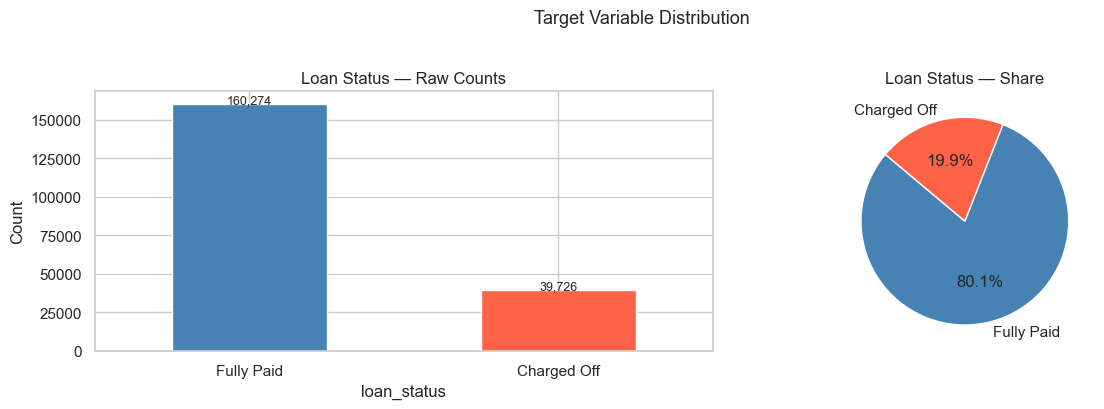

loan_status
Fully Paid     160274
Charged Off     39726
Name: count, dtype: int64


In [80]:
# ── 3.1 Target class distribution 
vc = df_raw['loan_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], rot=0, edgecolor='white')
axes[0].set_title('Loan Status — Raw Counts')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, vc):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=9)

axes[1].pie(vc, labels=vc.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=140,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Loan Status — Share')

plt.suptitle('Target Variable Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(vc)

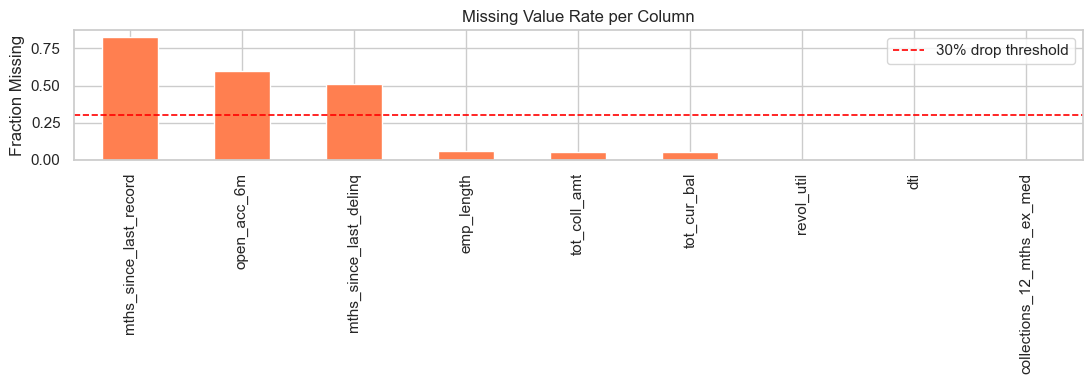

Columns with >30% missing (will be dropped):
mths_since_last_record   0.830
open_acc_6m              0.600
mths_since_last_delinq   0.507


In [81]:
# Missing value profile 
miss_pct = df_raw.isnull().mean().sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

plt.figure(figsize=(11, 4))
miss_pct.plot(kind='bar', color='coral', edgecolor='white')
plt.axhline(0.30, color='red', linestyle='--', linewidth=1.2, label='30% drop threshold')
plt.title('Missing Value Rate per Column')
plt.ylabel('Fraction Missing')
plt.legend()
plt.tight_layout()
plt.show()

print('Columns with >30% missing (will be dropped):')
print(miss_pct[miss_pct > 0.30].to_string())

In [82]:
# 3.3  Numeric summary statistics 
num_cols_eda = ['loan_amnt', 'int_rate', 'installment',
                'annual_inc', 'dti', 'revol_util']
df_raw[num_cols_eda].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,200000.000,14425.010,8725.750,500.000,8000.000,12000.000,20000.000,40000.000
int_rate,200000.000,13.240,4.770,5.310,9.750,12.740,15.990,30.990
installment,200000.000,438.260,261.450,15.690,248.820,374.330,581.580,1719.830
annual_inc,200000.000,76155.870,67888.270,0.000,45742.190,65000.000,90000.000,8400000.000
dti,199948.000,18.280,11.180,0.000,11.820,17.630,24.010,999.000
revol_util,199867.000,51.870,24.480,0.000,33.500,52.300,70.800,182.800


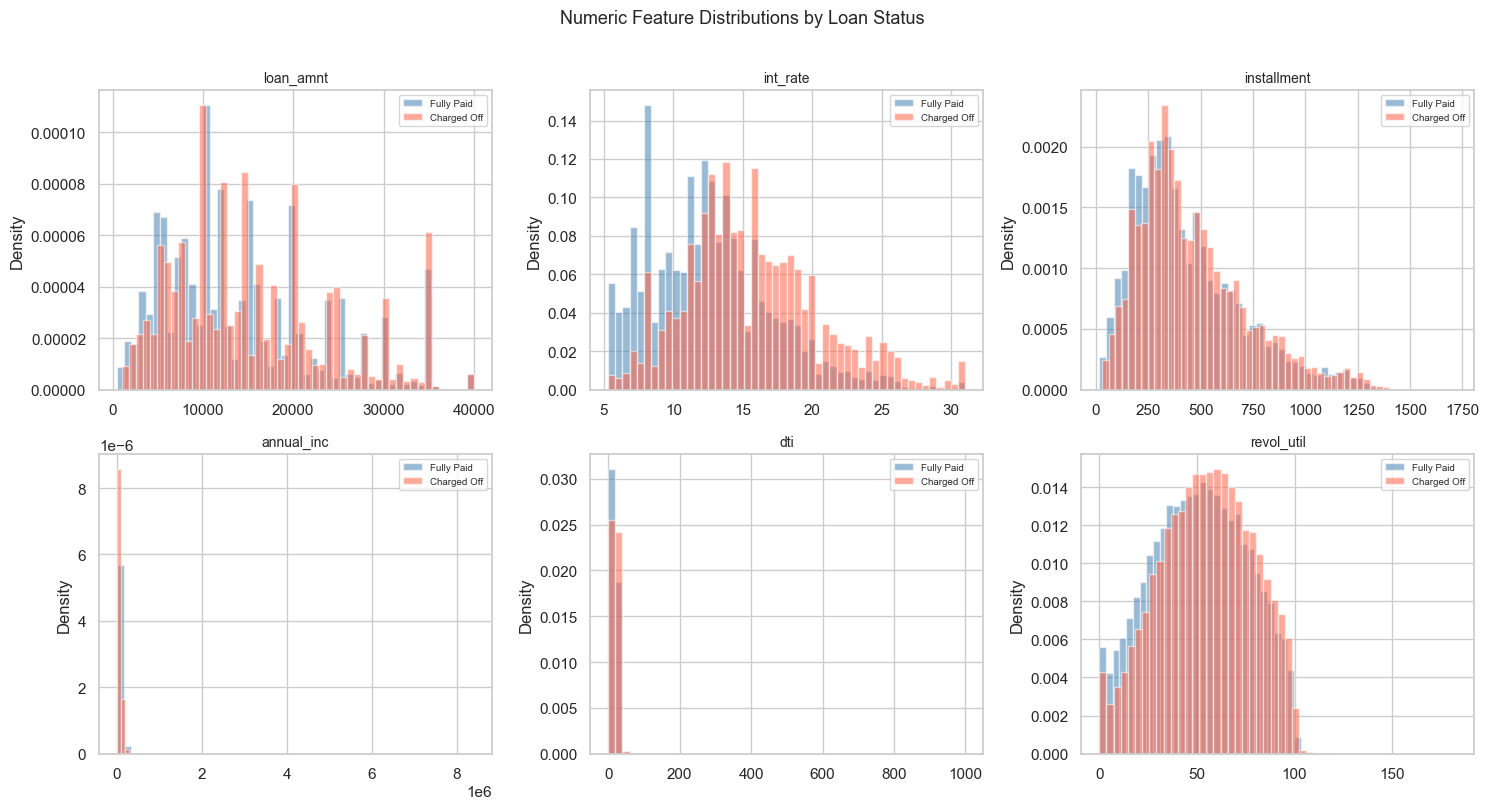

In [83]:
# 3.4  Numeric distributions split by outcome 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols_eda):
    for status, color in [('Fully Paid', 'steelblue'), ('Charged Off', 'tomato')]:
        data = df_raw.loc[df_raw['loan_status'] == status, col].dropna()
        ax.hist(data, bins=50, alpha=0.55, color=color, label=status, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('Numeric Feature Distributions by Loan Status', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

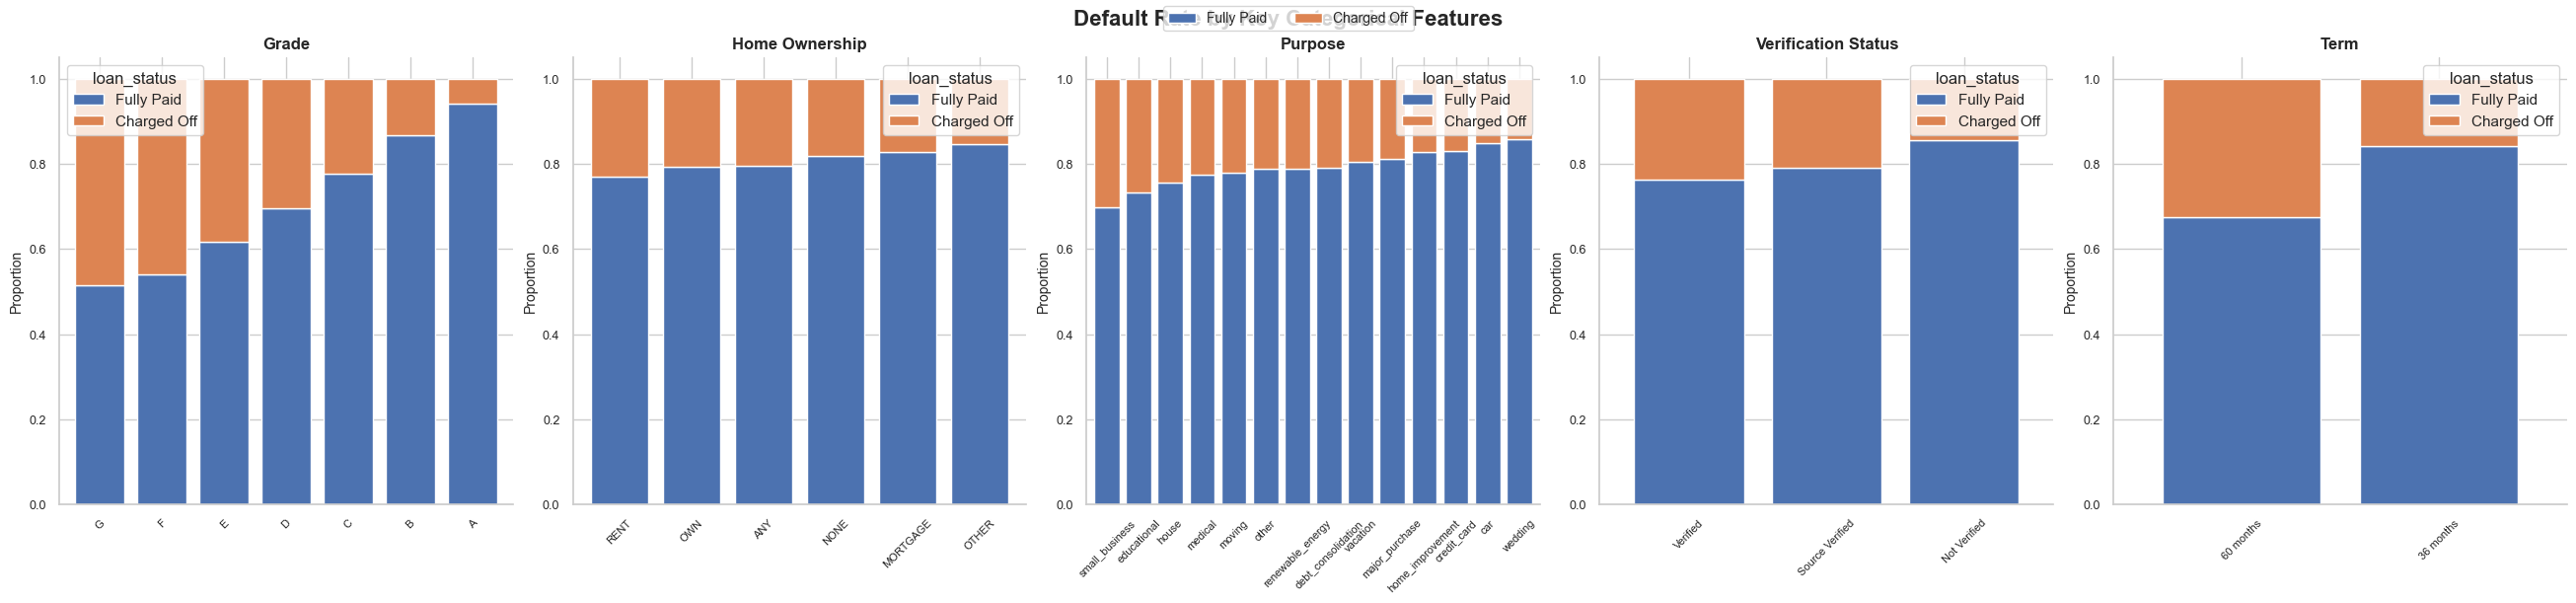

In [84]:
import matplotlib.pyplot as plt

cat_cols_eda = ['grade', 'home_ownership', 'purpose', 'verification_status', 'term']

fig, axes = plt.subplots(1, len(cat_cols_eda), figsize=(26, 6), constrained_layout=True)

for ax, col in zip(axes, cat_cols_eda):
    
    ct = (
        df_raw.groupby(col)['loan_status']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )

    # Sort by default rate (better storytelling)
    ct = ct.sort_values('Charged Off', ascending=False)

    # Plot
    ct[['Fully Paid', 'Charged Off']].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=['#4C72B0', '#DD8452'],
        width=0.8
    )

    # Titles & labels
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion', fontsize=10)

    # Improve x-label readability
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=9)

    # Remove spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Global title
plt.suptitle('Default Rate by Key Categorical Features', fontsize=16, fontweight='bold')

# Better legend placement
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=10)

plt.show()

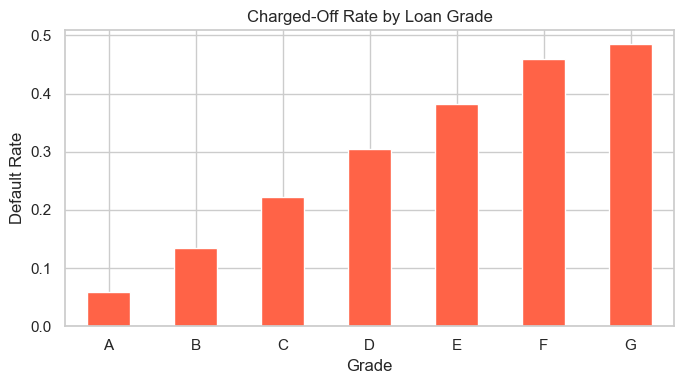

In [85]:
# 3.6  Default rate by loan grade (clear monotonic signal)
grade_default = (
    df_raw[df_raw['loan_status'].isin(TARGET_CLASSES)]
    .groupby('grade')['loan_status']
    .apply(lambda x: (x == 'Charged Off').mean())
    .loc[list('ABCDEFG')]
)
plt.figure(figsize=(7, 4))
grade_default.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Charged-Off Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.xlabel('Grade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

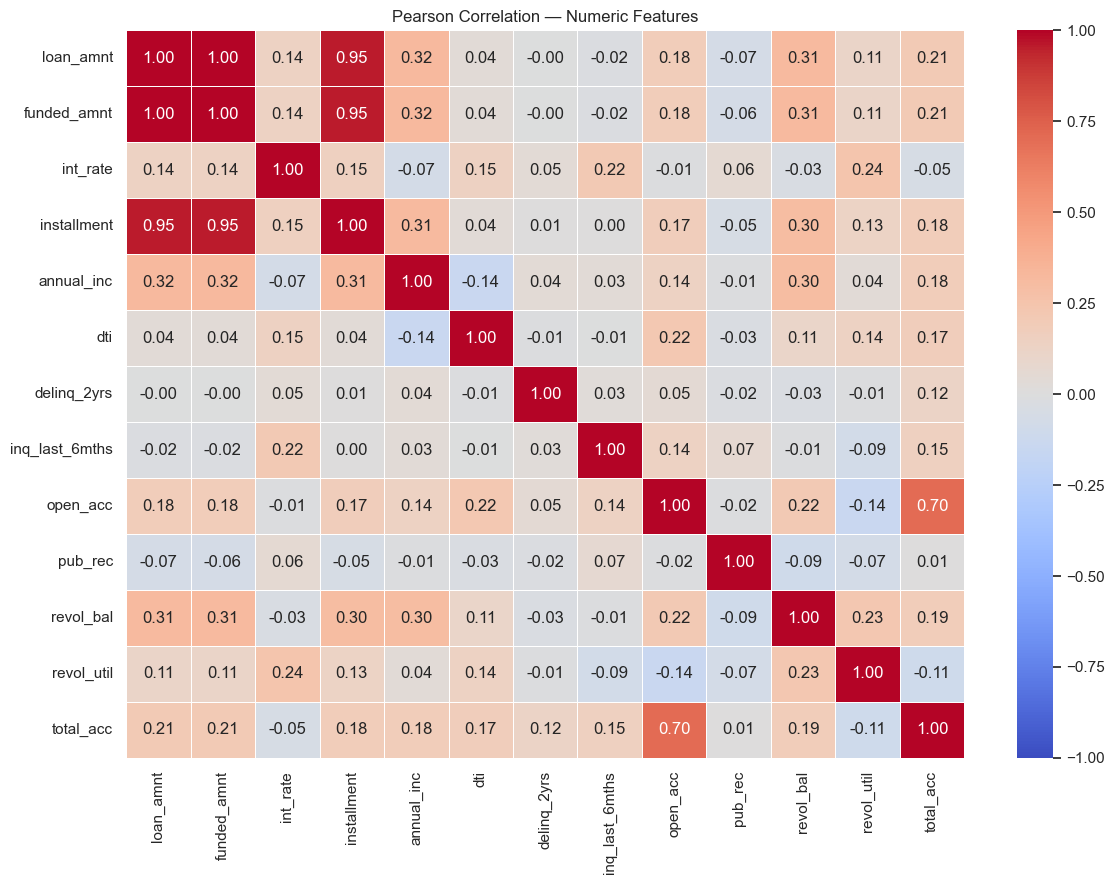

In [86]:
# 3.7  Pearson correlation heatmap 
corr_cols = [
    'loan_amnt', 'funded_amnt', 'int_rate', 'installment',
    'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc'
]
plt.figure(figsize=(12, 9))
sns.heatmap(
    df_raw[corr_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    linewidths=0.4, vmin=-1, vmax=1
)
plt.title('Pearson Correlation — Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Data Cleaning

Steps applied in order:
1. Filter to the two terminal loan statuses and encode the target
2. Drop columns with more than 30% missing values
3. Strip percent signs from string-encoded numeric columns
4. Parse `term` and `emp_length` into numeric values
5. Cap extreme outliers at the 99th percentile (right-skewed distributions)
6. Impute remaining nulls: median for numerics, mode for categoricals

In [87]:
df = df_raw.copy()

# Step 1: Filter and encode target 
df = df[df['loan_status'].isin(TARGET_CLASSES)].copy()
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)
df.drop(columns=['loan_status'], inplace=True)

print(f'Rows after filtering: {len(df):,}')
print(f'\nTarget distribution:')
print(df['target'].value_counts())
print(f'\nDefault rate: {df["target"].mean():.2%}')

Rows after filtering: 200,000

Target distribution:
target
0    160274
1     39726
Name: count, dtype: int64

Default rate: 19.86%


In [88]:
# Step 2: Drop high-missingness columns (>30%) 
hi_miss = miss_pct[miss_pct > 0.30].index.tolist()
drop_hi  = [c for c in hi_miss if c in df.columns]
df.drop(columns=drop_hi, inplace=True)
print(f'Dropped {len(drop_hi)} high-miss columns: {drop_hi}')

# Step 3: Parse percentage strings to float
for col in ['int_rate', 'revol_util']:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace('%', '', regex=False).astype(float)

# Step 4a: Term — extract number of months 
if 'term' in df.columns and df['term'].dtype == object:
    df['term'] = df['term'].str.strip().str.extract(r'(\d+)').astype(float)

# Step 4b: Employment length — map text to years
if 'emp_length' in df.columns:
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8,  '9 years': 9, '10+ years': 10
    }
    df['emp_length'] = df['emp_length'].map(emp_map)

# Step 5: Cap extreme outliers at the 99th percentile 
outlier_cols = ['annual_inc', 'revol_bal', 'tot_cur_bal', 'tot_coll_amt', 'loan_amnt']
for col in [c for c in outlier_cols if c in df.columns]:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

# Step 6: Impute nulls 
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')
print(f'Shape after cleaning: {df.shape}')

Dropped 3 high-miss columns: ['mths_since_last_record', 'open_acc_6m', 'mths_since_last_delinq']

Remaining nulls: 0
Shape after cleaning: (200000, 31)



## 5. Feature Engineering


In [89]:
# Issue date → year + month 
if 'issue_d' in df.columns:
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['issue_year']  = df['issue_d'].dt.year
    df['issue_month'] = df['issue_d'].dt.month
    df.drop(columns=['issue_d'], inplace=True)

# Credit history length in months 
if 'earliest_cr_line' in df.columns:
    df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'],
                                             format='%b-%Y', errors='coerce')
    ref = pd.Timestamp('2018-12-31')
    # Fix: divide by days (30.4375 = avg days per month) instead of np.timedelta64(1,'M')
    df['cr_hist_months'] = ((ref - df['earliest_cr_line']).dt.days / 30.4375).round()
    df.drop(columns=['earliest_cr_line'], inplace=True)

# Ratio / interaction features 
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
df['loan_to_income']        = df['loan_amnt']   / (df['annual_inc'] + 1)
df['funded_ratio']          = df['funded_amnt'] / (df['loan_amnt']  + 1)

# Grade — ordinal encoding (A < B < … < G) 
if 'grade' in df.columns:
    grade_order = {g: i for i, g in enumerate('ABCDEFG')}
    df['grade_num'] = df['grade'].map(grade_order)
    df.drop(columns=['grade'], inplace=True)

# Sub-grade — ordinal encoding (A1=0 … G5=34)
if 'sub_grade' in df.columns:
    sub_order = {f'{g}{n}': i*5 + (n-1)
                 for i, g in enumerate('ABCDEFG')
                 for n in range(1, 6)}
    df['sub_grade_num'] = df['sub_grade'].map(sub_order)
    df.drop(columns=['sub_grade'], inplace=True)

# One-hot encode remaining low-cardinality categoricals 
cat_final = df.select_dtypes(include='object').columns.tolist()
print(f'One-hot encoding {len(cat_final)} columns: {cat_final}')
df = pd.get_dummies(df, columns=cat_final, drop_first=True)

print(f'\nFinal feature matrix shape: {df.shape}')
df.head(2)


One-hot encoding 7 columns: ['term', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']

Final feature matrix shape: (200000, 100)


,loan_amnt,funded_amnt,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,target,issue_year,issue_month,cr_hist_months,installment_to_income,loan_to_income,funded_ratio,grade_num,sub_grade_num,term_ 60 months,home_ownership_MORTGAGE,...,addr_state_MN,addr_state_MO,addr_state_MS,addr_state_MT,addr_state_NC,addr_state_ND,addr_state_NE,addr_state_NH,addr_state_NJ,addr_state_NM,addr_state_NV,addr_state_NY,addr_state_OH,addr_state_OK,addr_state_OR,addr_state_PA,addr_state_RI,addr_state_SC,addr_state_SD,addr_state_TN,addr_state_TX,addr_state_UT,addr_state_VA,addr_state_VT,addr_state_WA,addr_state_WI,addr_state_WV,addr_state_WY,initial_list_status_w,application_type_Joint App
0,8000.000,8000.000,7.690,249.550,1.000,80000.000,8.730,0.000,1.000,11.000,0.000,7141.000,39.900,30.000,6869.770,0.000,0.000,250.000,180248.000,0,2014,8,220.000,0.037,0.100,1.000,0,3,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,12000.000,12000.000,15.050,416.280,0.000,36000.000,17.860,0.000,1.000,7.000,0.000,4374.000,58.300,13.000,8120.540,0.000,0.000,0.000,24595.000,0,2017,6,159.000,0.139,0.333,1.000,2,13,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True



## 6. Train / Test Split

In [90]:
X = df.drop(columns=['target'])
y = df['target']

# Stratified split preserves the ~20% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]:>8,} rows  |  default rate: {y_train.mean():.2%}')
print(f'Test set     : {X_test.shape[0]:>8,} rows  |  default rate: {y_test.mean():.2%}')

Training set :  160,000 rows  |  default rate: 19.86%
Test set     :   40,000 rows  |  default rate: 19.86%



## 7. SMOTE — Handling Class Imbalance

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic *Charged Off* samples by interpolating between existing minority-class observations in feature space.  
Applied **only to the training set** — the test set is kept at the natural 80/20 ratio so evaluation reflects real-world conditions.

Before SMOTE: {0: 128219, 1: 31781}
After  SMOTE: {0: 128219, 1: 128219}


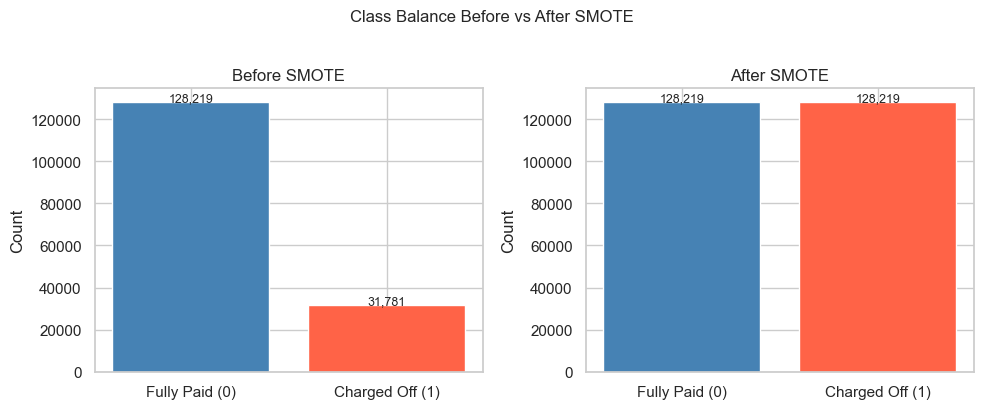

In [91]:
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After  SMOTE:', pd.Series(y_train_sm).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['Fully Paid (0)', 'Charged Off (1)']
colors = ['steelblue', 'tomato']
for ax, (vals, title) in zip(axes, [
    (y_train,              'Before SMOTE'),
    (pd.Series(y_train_sm), 'After SMOTE'),
]):
    vc = vals.value_counts().sort_index()
    bars = ax.bar(labels, vc, color=colors, edgecolor='white')
    for bar, val in zip(bars, vc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val:,}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Count')

plt.suptitle('Class Balance Before vs After SMOTE', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 8. Feature Scaling

StandardScaler is fit **only on the SMOTE-augmented training set** and then applied to the test set.  
Tree-based models (Decision Tree, Random Forest, XGBoost) are scale-invariant, so we keep both scaled and unscaled versions.

In [92]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)   # scaled — for Logistic Regression
X_test_sc  = scaler.transform(X_test)

print('Scaled training set shape :', X_train_sc.shape)
print('Unscaled training set shape:', X_train_sm.shape)

Scaled training set shape : (256438, 99)
Unscaled training set shape: (256438, 99)



## 9. Baseline Model Training

### Helper — evaluate_model()

In [93]:
results = {}   # accumulates {model_name: metric_dict} for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Fit `model` on (X_tr, y_tr), evaluate on (X_te, y_te).
    Prints classification report, plots confusion matrix + ROC curve.
    Stores key metrics in the global `results` dict.
    Returns the fitted model.
    """
    model.fit(X_tr, y_tr)

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    roc_auc = roc_auc_score(y_te, y_proba)
    report  = classification_report(
        y_te, y_pred,
        target_names=['Fully Paid', 'Charged Off'],
        output_dict=True
    )

    print(f'\n{"─"*65}')
    print(f'  {name}')
    print(f'{"─"*65}')
    print(classification_report(y_te, y_pred,
                                target_names=['Fully Paid', 'Charged Off']))
    print(f'  ROC-AUC : {roc_auc:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['Fully Paid', 'Charged Off'],
        cmap='Blues', ax=axes[0]
    )
    axes[0].set_title(f'{name} — Confusion Matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    results[name] = {
        'Accuracy' : report['accuracy'],
        'Precision': report['Charged Off']['precision'],
        'Recall'   : report['Charged Off']['recall'],
        'F1'       : report['Charged Off']['f1-score'],
        'ROC-AUC'  : roc_auc,
    }
    return model

### 9.1 Logistic Regression
Linear baseline. Uses the scaled feature matrix. Interpretable coefficients.


─────────────────────────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Fully Paid       0.91      0.94      0.93     32055
 Charged Off       0.73      0.61      0.67      7945

    accuracy                           0.88     40000
   macro avg       0.82      0.78      0.80     40000
weighted avg       0.87      0.88      0.87     40000

  ROC-AUC : 0.9300


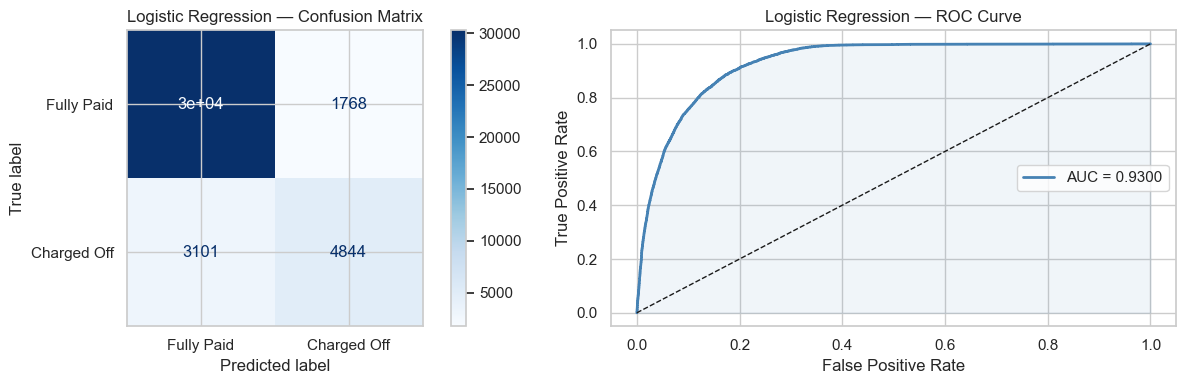

In [94]:
lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED)
lr = evaluate_model('Logistic Regression', lr,
                    X_train_sc, y_train_sm,
                    X_test_sc,  y_test)

### 9.2 Decision Tree
Single tree — fully interpretable. Depth-limited to reduce overfitting.


─────────────────────────────────────────────────────────────────
  Decision Tree
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Fully Paid       0.95      0.86      0.90     32055
 Charged Off       0.59      0.83      0.69      7945

    accuracy                           0.85     40000
   macro avg       0.77      0.85      0.80     40000
weighted avg       0.88      0.85      0.86     40000

  ROC-AUC : 0.9343


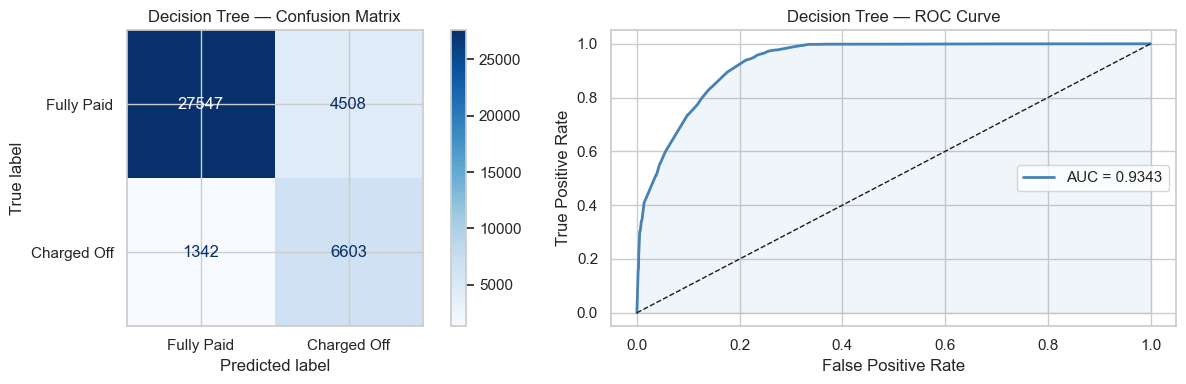

In [95]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=SEED
)
dt = evaluate_model('Decision Tree', dt,
                    X_train_sm, y_train_sm,
                    X_test,     y_test)

### 9.3 Random Forest
Ensemble of 200 trees with bagging. More robust than a single decision tree. Uses unscaled data (tree methods are scale-invariant).


─────────────────────────────────────────────────────────────────
  Random Forest
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Fully Paid       0.94      0.90      0.92     32055
 Charged Off       0.66      0.76      0.70      7945

    accuracy                           0.87     40000
   macro avg       0.80      0.83      0.81     40000
weighted avg       0.88      0.87      0.88     40000

  ROC-AUC : 0.9330


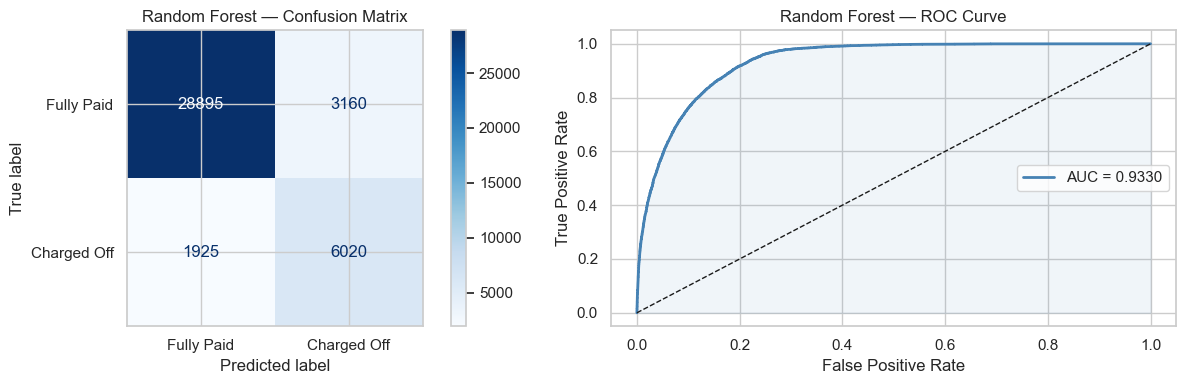

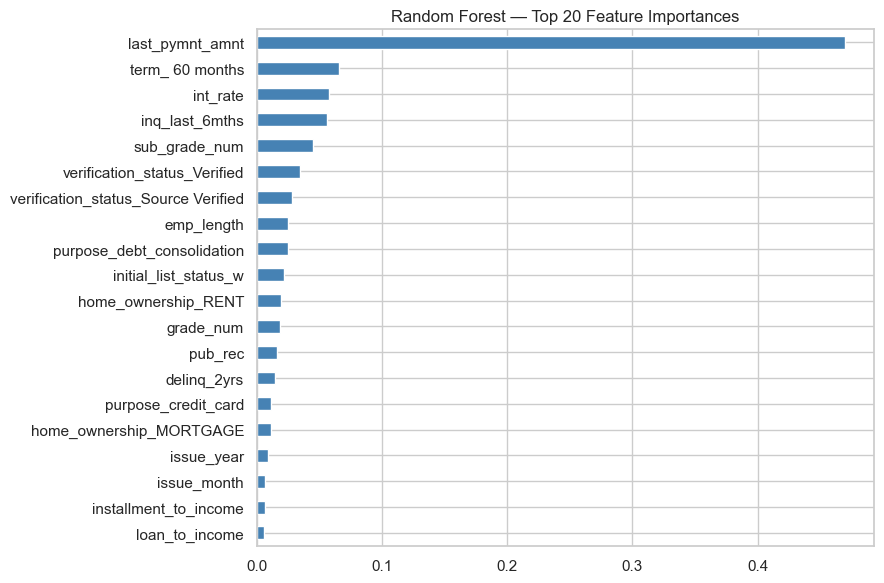

In [96]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=30,
    n_jobs=-1,
    random_state=SEED
)
rf = evaluate_model('Random Forest', rf,
                    X_train_sm, y_train_sm,
                    X_test,     y_test)

# Feature importance
feat_imp_rf = pd.Series(rf.feature_importances_, index=X.columns).nlargest(20).sort_values()
plt.figure(figsize=(9, 6))
feat_imp_rf.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

### 9.4 XGBoost (Default Params)
Gradient-boosted trees. `scale_pos_weight` compensates for class imbalance using the **original** (pre-SMOTE) class ratio, since SMOTE already balanced the training labels.

Original class ratio  →  Fully Paid: 128,219  |  Charged Off: 31,781
scale_pos_weight = 4.03

─────────────────────────────────────────────────────────────────
  XGBoost (default)
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Fully Paid       0.98      0.82      0.89     32055
 Charged Off       0.57      0.94      0.71      7945

    accuracy                           0.84     40000
   macro avg       0.77      0.88      0.80     40000
weighted avg       0.90      0.84      0.86     40000

  ROC-AUC : 0.9557


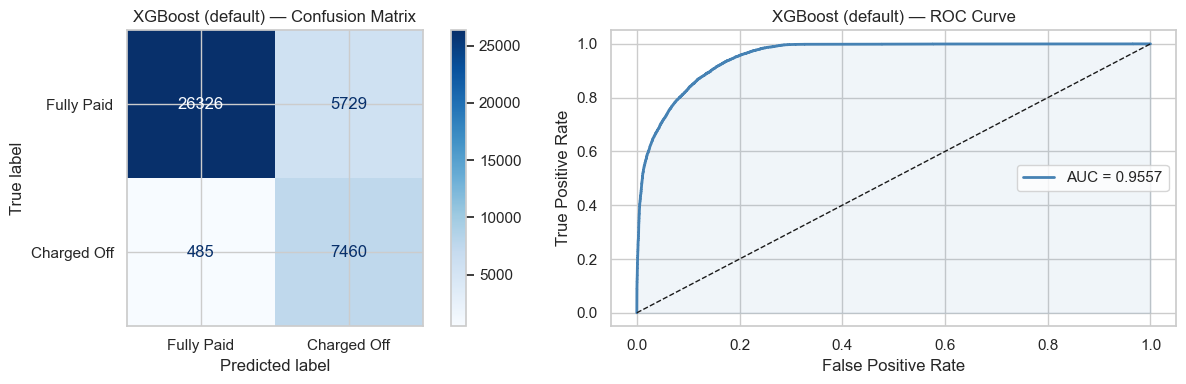

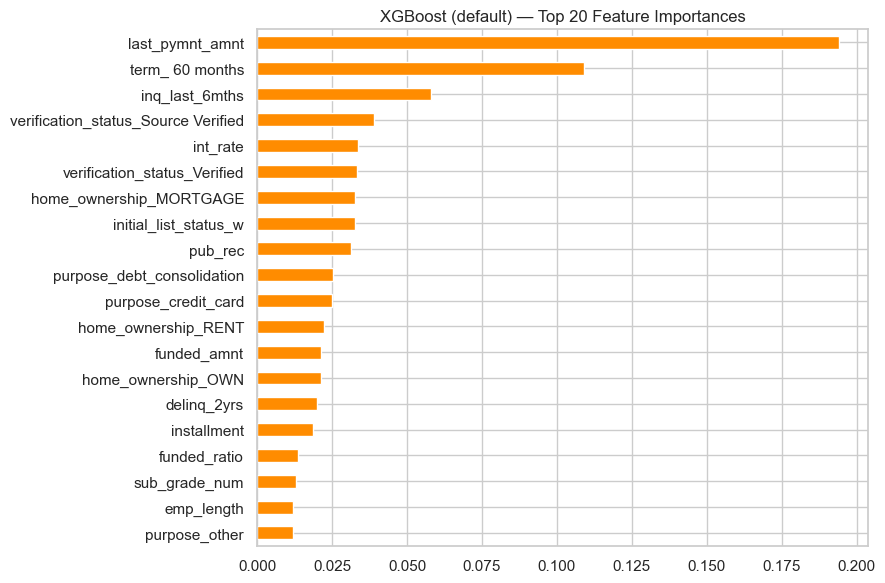

In [97]:
# scale_pos_weight = majority / minority from original (pre-SMOTE) training labels
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f'Original class ratio  →  Fully Paid: {neg_count:,}  |  Charged Off: {pos_count:,}')
print(f'scale_pos_weight = {spw:.2f}')

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=spw,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=SEED
)
xgb = evaluate_model('XGBoost (default)', xgb,
                      X_train_sm, y_train_sm,
                      X_test,     y_test)

feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X.columns).nlargest(20).sort_values()
plt.figure(figsize=(9, 6))
feat_imp_xgb.plot(kind='barh', color='darkorange')
plt.title('XGBoost (default) — Top 20 Feature Importances')
plt.tight_layout()
plt.show()


## 10. Hyperparameter Tuning — XGBoost with Optuna

**Why Optuna over GridSearchCV?**
- Bayesian-style search (Tree-structured Parzen Estimator) — finds good regions of the search space much faster than exhaustive grid search.
- `timeout=300` caps the run at 5 minutes regardless of `n_trials`.
- We tune on a 50 k-row subsample of the SMOTE training data with 3-fold CV to keep wall-clock time reasonable. The best parameters are then retrained on the full training set.

**Search space:**

| Parameter | Range | Scale |
|---|---|---|
| `n_estimators` | 100 – 600 | linear |
| `max_depth` | 3 – 10 | linear |
| `learning_rate` | 0.005 – 0.3 | log |
| `subsample` | 0.5 – 1.0 | linear |
| `colsample_bytree` | 0.5 – 1.0 | linear |
| `min_child_weight` | 1 – 20 | linear |
| `reg_alpha` (L1) | 1e-8 – 10 | log |
| `reg_lambda` (L2) | 1e-8 – 10 | log |
| `gamma` | 0 – 5 | linear |

In [98]:
# Subsample for tuning speed 
# We tune on 50k rows; the winning params are then retrained on the full set
TUNE_N = min(50_000, len(X_train_sm))

idx_tune = np.random.RandomState(SEED).choice(
    len(X_train_sm), size=TUNE_N, replace=False
)
X_tune = X_train_sm.iloc[idx_tune] if hasattr(X_train_sm, 'iloc') \
         else X_train_sm[idx_tune]
y_tune = np.array(y_train_sm)[idx_tune]

print(f'Tuning on {TUNE_N:,} rows  |  default rate: {y_tune.mean():.2%}')

Tuning on 50,000 rows  |  default rate: 50.34%


In [99]:
def objective(trial):
    """Optuna objective — maximise 3-fold CV ROC-AUC on the tuning subset."""
    params = {
        'n_estimators'     : trial.suggest_int  ('n_estimators',      100, 600),
        'max_depth'        : trial.suggest_int  ('max_depth',           3,  10),
        'learning_rate'    : trial.suggest_float('learning_rate',    0.005, 0.30, log=True),
        'subsample'        : trial.suggest_float('subsample',          0.5,  1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree',   0.5,  1.0),
        'min_child_weight' : trial.suggest_int  ('min_child_weight',     1,  20),
        'reg_alpha'        : trial.suggest_float('reg_alpha',         1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda',        1e-8, 10.0, log=True),
        'gamma'            : trial.suggest_float('gamma',              0.0,  5.0),
    }
    model = XGBClassifier(
        **params,
        scale_pos_weight=spw,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
        random_state=SEED
    )
    cv_scores = cross_val_score(
        model, X_tune, y_tune,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring='roc_auc',
        n_jobs=-1
    )
    return cv_scores.mean()


print('Starting Optuna study … (50 trials, 5-min cap)')
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, timeout=300, show_progress_bar=True)

print(f'\nBest CV ROC-AUC : {study.best_value:.4f}')
print(f'Best parameters :')
for k, v in study.best_params.items():
    print(f'  {k:<22}: {v}')

Starting Optuna study … (50 trials, 5-min cap)


  0%|          | 0/50 [00:00<?, ?it/s]


Best CV ROC-AUC : 0.9872
Best parameters :
  n_estimators          : 474
  max_depth             : 4
  learning_rate         : 0.11304022004782562
  subsample             : 0.7678100944290523
  colsample_bytree      : 0.9446770372505513
  min_child_weight      : 14
  reg_alpha             : 9.117833456454997e-08
  reg_lambda            : 0.009652139641464488
  gamma                 : 2.9470908145325083


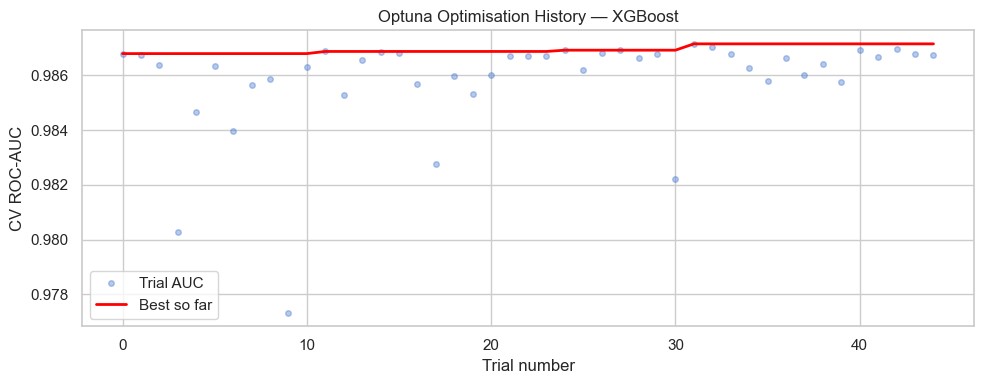

In [100]:
# Optuna optimisation history 
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = pd.Series(trial_values).cummax()

plt.figure(figsize=(10, 4))
plt.plot(trial_values, 'o', alpha=0.4, markersize=4, label='Trial AUC')
plt.plot(best_so_far, lw=2, color='red', label='Best so far')
plt.xlabel('Trial number')
plt.ylabel('CV ROC-AUC')
plt.title('Optuna Optimisation History — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

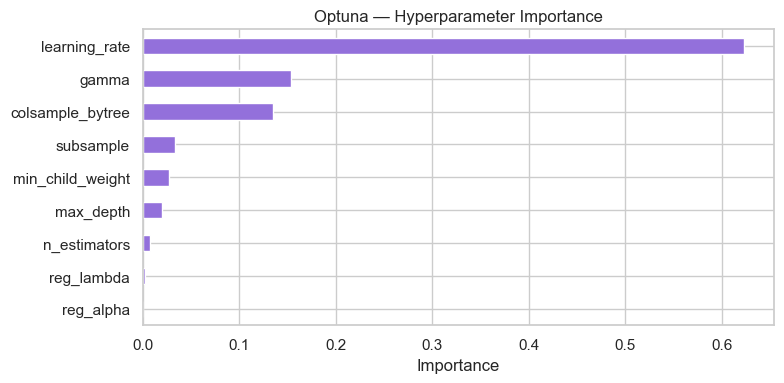

In [101]:
# Parameter importance (which params mattered most?) 
try:
    param_imp = optuna.importance.get_param_importances(study)
    pi_series = pd.Series(param_imp).sort_values()
    plt.figure(figsize=(8, 4))
    pi_series.plot(kind='barh', color='mediumpurple')
    plt.title('Optuna — Hyperparameter Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'Parameter importance not available: {e}')

### 10.1 Retrain Best XGBoost on Full Training Set


─────────────────────────────────────────────────────────────────
  XGBoost (Optuna tuned)
─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Fully Paid       0.98      0.83      0.90     32055
 Charged Off       0.58      0.93      0.72      7945

    accuracy                           0.85     40000
   macro avg       0.78      0.88      0.81     40000
weighted avg       0.90      0.85      0.86     40000

  ROC-AUC : 0.9581


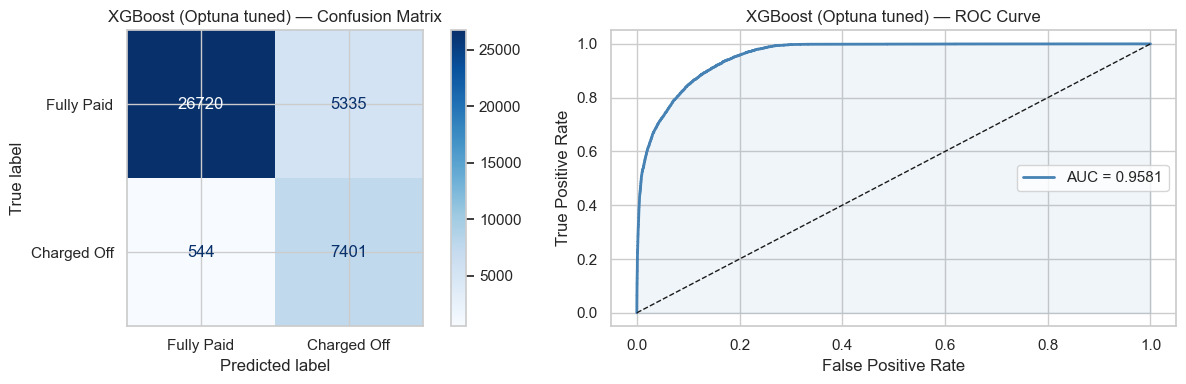

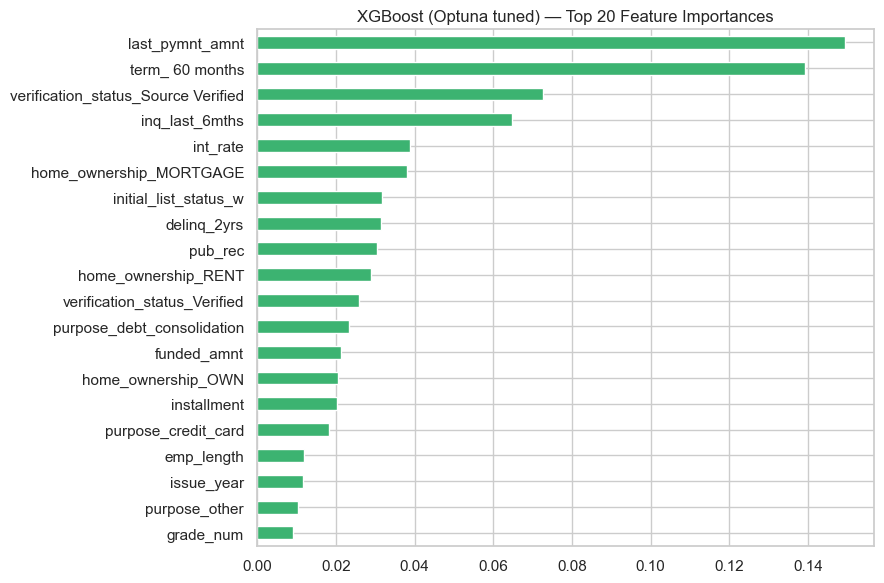

In [102]:
xgb_tuned = XGBClassifier(
    **study.best_params,
    scale_pos_weight=spw,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=SEED
)
xgb_tuned = evaluate_model('XGBoost (Optuna tuned)', xgb_tuned,
                            X_train_sm, y_train_sm,
                            X_test,     y_test)

feat_imp_tuned = (
    pd.Series(xgb_tuned.feature_importances_, index=X.columns)
    .nlargest(20)
    .sort_values()
)
plt.figure(figsize=(9, 6))
feat_imp_tuned.plot(kind='barh', color='mediumseagreen')
plt.title('XGBoost (Optuna tuned) — Top 20 Feature Importances')
plt.tight_layout()
plt.show()


## 11. Model Comparison

In [103]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df = results_df.round(4)
print(results_df.to_string())

                        Accuracy  Precision  Recall    F1  ROC-AUC
XGBoost (Optuna tuned)     0.853      0.581   0.931 0.716    0.958
XGBoost (default)          0.845      0.566   0.939 0.706    0.956
Decision Tree              0.854      0.594   0.831 0.693    0.934
Random Forest              0.873      0.656   0.758 0.703    0.933
Logistic Regression        0.878      0.733   0.610 0.665    0.930



## 12. ROC & Precision-Recall Curves — All Models

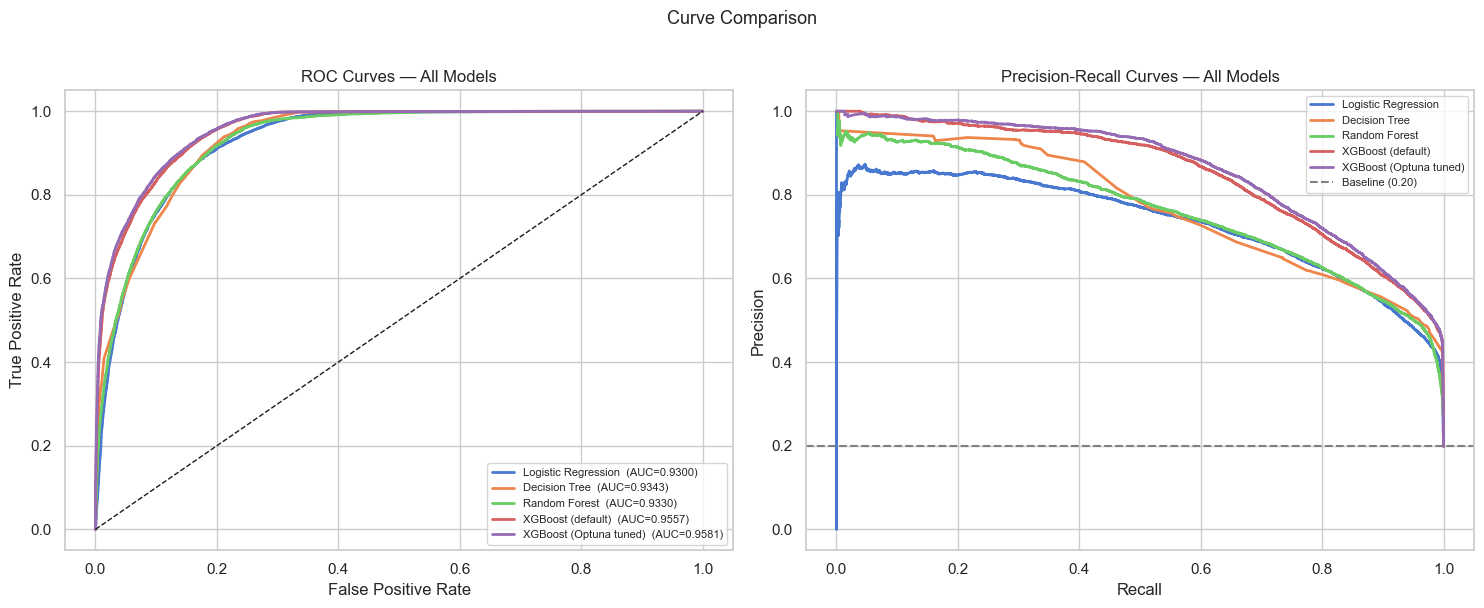

In [104]:
# Map model objects to the correct feature matrix version
model_map = {
    'Logistic Regression'   : (lr,        X_test_sc),
    'Decision Tree'         : (dt,        X_test),
    'Random Forest'         : (rf,        X_test),
    'XGBoost (default)'     : (xgb,       X_test),
    'XGBoost (Optuna tuned)': (xgb_tuned, X_test),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for name, (model, Xte) in model_map.items():
    proba = model.predict_proba(Xte)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name}  (AUC={auc:.4f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, lw=2, label=name)

# ROC diagonal
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=8, loc='lower right')

# PR baseline
axes[1].axhline(y_test.mean(), linestyle='--', color='grey',
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(fontsize=8)

plt.suptitle('Curve Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 13. Summary & Next Steps

### Model Trade-offs

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Fast, interpretable, good probability calibration | Underperforms on non-linear patterns |
| Decision Tree | Fully human-readable splits | High variance, prone to overfitting |
| Random Forest | Robust ensemble, low variance | Slower inference, less interpretable |
| XGBoost (default) | Strong out-of-the-box performance | Sensitive to hyperparameters |
| XGBoost (Optuna) | Best overall AUC, optimised trade-offs | Slowest to train |

